# Automated Essay Scoring — Full Pipeline 


- **All 8 essay sets** used (up from essay set 1 only)
- **Per-set score normalization** via `groupby` transform (each set has its own min/max)
- **Model upgraded** from `RandomForestRegressor` → `GradientBoostingRegressor` (same hyperparams as `model.py`)
- **5 new features** added (21 total, up from 16):
  - `punctuation_count` — total `.,:;!?` characters
  - `comma_count` — total commas
  - `transition_count` — count of transition words/phrases used
  - `grammar_error_rate` — grammar errors normalized by word count
  - `sentence_length_variance` — variance in per-sentence word counts
- **`tqdm` progress bar** added for feature extraction
- Score report updated to show all 21 features
- Comparison test updated to reflect GradientBoosting output

## Step 1 — Import Libraries

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

from textblob import TextBlob
import language_tool_python
import spacy
from tqdm import tqdm

from nltk.corpus import stopwords

nltk.download('punkt',                   quiet=True)
nltk.download('punkt_tab',               quiet=True)
nltk.download('stopwords',               quiet=True)
nltk.download('averaged_perceptron_tagger',     quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

import os
print(os.getcwd())
print('All libraries imported successfully!')

C:\Users\kingm
All libraries imported successfully!


In [23]:
# Initialize grammar checker and spaCy model (do this once — slow to reload)
stop_words = set(stopwords.words('english'))

print('Loading grammar tool (may take ~30 seconds on first run)...')
grammar_tool = language_tool_python.LanguageTool('en-US')

print('Loading spaCy model...')
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    print('en_core_web_sm not found — downloading now...')
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

print('All tools loaded!')

Loading grammar tool (may take ~30 seconds on first run)...
Loading spaCy model...
All tools loaded!


## Step 2 — Load Dataset

In [5]:
import os

# Add more locations here if needed
candidates = [
    'training_set_rel3.tsv',
    os.path.join('TASK-03', 'training_set_rel3.tsv'),
    os.path.join(os.path.expanduser('~'), 'Desktop', 'RhombixTechnologies', 'TASK-03', 'training_set_rel3.tsv'),
]

DATA_FILE = next((p for p in candidates if os.path.exists(p)), None)
if DATA_FILE is None:
    raise FileNotFoundError(
        "training_set_rel3.tsv not found. Add its actual path to the 'candidates' list above."
    )

print('Loading from:', DATA_FILE)
df_full = pd.read_csv(DATA_FILE, sep='\t', encoding='latin-1')
df = df_full.copy() 
print('Dataset shape:', df_full.shape)
print('\nColumns:', df_full.columns.tolist())
df_full.head()

Loading from: C:\Users\kingm\Desktop\RhombixTechnologies\TASK-03\training_set_rel3.tsv
Dataset shape: (12976, 28)

Columns: ['essay_id', 'essay_set', 'essay', 'rater1_domain1', 'rater2_domain1', 'rater3_domain1', 'domain1_score', 'rater1_domain2', 'rater2_domain2', 'domain2_score', 'rater1_trait1', 'rater1_trait2', 'rater1_trait3', 'rater1_trait4', 'rater1_trait5', 'rater1_trait6', 'rater2_trait1', 'rater2_trait2', 'rater2_trait3', 'rater2_trait4', 'rater2_trait5', 'rater2_trait6', 'rater3_trait1', 'rater3_trait2', 'rater3_trait3', 'rater3_trait4', 'rater3_trait5', 'rater3_trait6']


,essay_id,essay_set,essay,rater1_domain1,rater2_domain1,rater3_domain1,domain1_score,rater1_domain2,rater2_domain2,domain2_score,...,rater2_trait3,rater2_trait4,rater2_trait5,rater2_trait6,rater3_trait1,rater3_trait2,rater3_trait3,rater3_trait4,rater3_trait5,rater3_trait6
0,1,1,"Dear local newspaper, I think effects computer...",4,4,NaN,8,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,1,"Dear @CAPS1 @CAPS2, I believe that using compu...",5,4,NaN,9,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,1,"Dear, @CAPS1 @CAPS2 @CAPS3 More and more peopl...",4,3,NaN,7,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,1,"Dear Local Newspaper, @CAPS1 I have found that...",5,5,NaN,10,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,1,"Dear @LOCATION1, I know having computers has a...",4,4,NaN,8,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Step 3 — Select Essay Sets & Normalize Scores

Each essay set uses a **different raw score scale**, so scores are normalized
per set to a common **0–10 scale** using min-max normalization:

```
score_normalized = (raw − set_min) / (set_max − set_min) × 10
```

This is identical to what `model.py` does via `groupby().transform()`.

In [6]:
# ---- ESSAY SET CONTROL ----
#
# OPTION A — Fast (2-3 hours): 4 sets
# SELECTED_SETS = [1, 2, 3, 4]
#
# OPTION B — Balanced (4-6 hours): 6 sets
# SELECTED_SETS = [1, 2, 3, 4, 5, 6]
#
# OPTION C — Full (6-12 hours, overnight): all 8 sets  ← matches model.py
SELECTED_SETS = [1, 2, 3, 4, 5, 6, 7, 8]
#
# OPTION D — Quick test only (~20-30 min): sample from 4 sets
# SELECTED_SETS = [1, 2, 3, 4]
# df = df[df['essay_set'].isin(SELECTED_SETS)].sample(500, random_state=42)
# ---- END ESSAY SET CONTROL ----

df = df[df['essay_set'].isin(SELECTED_SETS)].copy()
df.reset_index(drop=True, inplace=True)

print(f'Training on essay sets: {SELECTED_SETS}')
print('Essays per set:')
print(df['essay_set'].value_counts().sort_index())
print(f'Total: {len(df)} essays')

# Per-set min-max normalization to 0-10
df['score_normalized'] = df.groupby('essay_set')['domain1_score'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) * 10
)

print(f'\nScore range after normalization: {df["score_normalized"].min():.1f} – {df["score_normalized"].max():.1f}')
df[['essay_set', 'domain1_score', 'score_normalized']].head(10)

Training on essay sets: [1, 2, 3, 4, 5, 6, 7, 8]
Essays per set:
essay_set
1    1783
2    1800
3    1726
4    1770
5    1805
6    1800
7    1569
8     723
Name: count, dtype: int64
Total: 12976 essays

Score range after normalization: 0.0 – 10.0


,essay_set,domain1_score,score_normalized
0,1,8,6.0
1,1,9,7.0
2,1,7,5.0
3,1,10,8.0
4,1,8,6.0
5,1,8,6.0
6,1,10,8.0
7,1,10,8.0
8,1,9,7.0
9,1,9,7.0


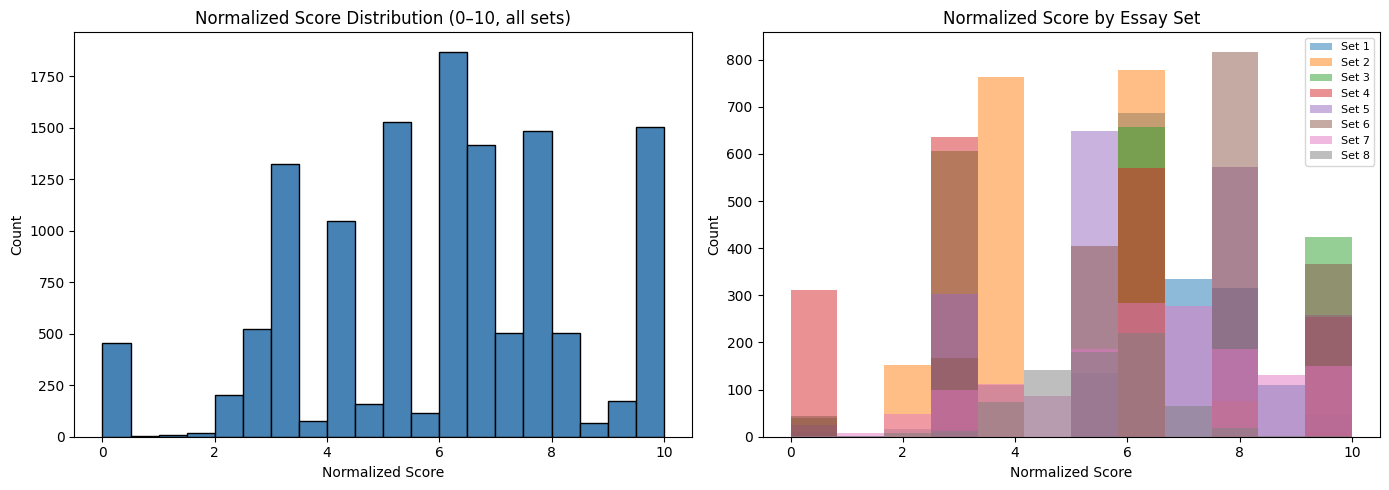

Chart saved!


In [7]:
# Visualize normalized score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normalized scores overall
axes[0].hist(df['score_normalized'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Normalized Score Distribution (0–10, all sets)')
axes[0].set_xlabel('Normalized Score')
axes[0].set_ylabel('Count')

# Per-set distribution
for s in SELECTED_SETS:
    subset = df[df['essay_set'] == s]['score_normalized']
    axes[1].hist(subset, bins=12, alpha=0.5, label=f'Set {s}')
axes[1].set_title('Normalized Score by Essay Set')
axes[1].set_xlabel('Normalized Score')
axes[1].set_ylabel('Count')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('score_distribution.png', dpi=150)
plt.show()
print('Chart saved!')

In [8]:
# Show a sample essay
print('Sample Essay (Set 1):')
print('-' * 60)
sample_row = df[df['essay_set'] == 1].iloc[0]
print(sample_row['essay'][:500], '...')
print('-' * 60)
print(f'Raw Score:        {sample_row["domain1_score"]}')
print(f'Normalized Score: {sample_row["score_normalized"]:.2f} / 10')

Sample Essay (Set 1):
------------------------------------------------------------
Dear local newspaper, I think effects computers have on people are great learning skills/affects because they give us time to chat with friends/new people, helps us learn about the globe(astronomy) and keeps us out of troble! Thing about! Dont you think so? How would you feel if your teenager is always on the phone with friends! Do you ever time to chat with your friends or buisness partner about things. Well now - there's a new way to chat the computer, theirs plenty of sites on the internet to ...
------------------------------------------------------------
Raw Score:        8
Normalized Score: 6.00 / 10


## Step 4 — Feature Engineering

We extract **21 features** per essay — identical to `model.py`:

| Feature | Description | Status |
|---|---|---|
| `word_count` | Total alphabetic words | same |
| `sentence_count` | Total sentences | same |
| `unique_words` | Distinct words | same |
| `avg_word_length` | Mean chars per word | same |
| `vocab_richness` | Root TTR (unique / √words) | same |
| `avg_sentence_length` | Words per sentence | same |
| `stopword_ratio` | Non-stopword fraction | same |
| `char_count` | Total characters | same |
| `paragraph_count` | Number of paragraphs | same |
| `pos_diversity` | Fraction of unique POS tags | same |
| `noun_ratio` | Fraction of words that are nouns | same |
| `verb_ratio` | Fraction of words that are verbs | same |
| `adj_ratio` | Fraction of words that are adjectives | same |
| `sentiment_polarity` | TextBlob sentiment (−1 to 1) | same |
| `grammar_error_count` | Grammar mistakes via LanguageTool | same |
| `named_entity_count` | Named entities via spaCy | same |
| `punctuation_count` | Count of `.,:;!?` chars | **NEW** |
| `comma_count` | Count of commas | **NEW** |
| `transition_count` | Count of transition words/phrases | **NEW** |
| `grammar_error_rate` | Grammar errors / word count | **NEW** |
| `sentence_length_variance` | Variance of per-sentence word counts | **NEW** |

In [9]:
TRANSITION_WORDS = [
    'however', 'furthermore', 'therefore', 'moreover', 'consequently',
    'nevertheless', 'in conclusion', 'in addition', 'on the other hand',
    'for example', 'for instance', 'in contrast', 'as a result',
    'in summary', 'to conclude', 'firstly', 'secondly', 'finally',
    'additionally', 'similarly', 'meanwhile', 'subsequently'
]

def extract_features(text):
    # --- Basic tokenization ---
    sentences  = nltk.sent_tokenize(text)
    words      = nltk.word_tokenize(text.lower())
    words_only = [w for w in words if w.isalpha()]
    non_stop_words = [w for w in words_only if w not in stop_words]

    word_count     = len(words_only)
    sentence_count = len(sentences)
    unique_words   = len(set(words_only))

    avg_word_length = np.mean([len(w) for w in words_only]) if words_only else 0

    # Root TTR — does not penalize longer essays
    vocab_richness = unique_words / (word_count ** 0.5) if word_count > 0 else 0

    avg_sentence_length = word_count / sentence_count if sentence_count > 0 else 0
    stopword_ratio      = len(non_stop_words) / word_count if word_count > 0 else 0
    char_count          = len(text)

    # Paragraph count
    paragraph_count = len([p for p in text.split('\n') if p.strip()])

    # POS tagging
    pos_tags  = nltk.pos_tag(words_only) if words_only else []
    pos_list  = [tag for _, tag in pos_tags]
    total_pos = len(pos_list)
    unique_pos = len(set(pos_list))
    pos_diversity = unique_pos / total_pos if total_pos > 0 else 0
    noun_ratio = sum(1 for t in pos_list if t.startswith('NN')) / total_pos if total_pos > 0 else 0
    verb_ratio = sum(1 for t in pos_list if t.startswith('VB')) / total_pos if total_pos > 0 else 0
    adj_ratio  = sum(1 for t in pos_list if t.startswith('JJ')) / total_pos if total_pos > 0 else 0

    # Sentiment
    sentiment_polarity = TextBlob(text).sentiment.polarity

    # Grammar errors
    grammar_error_count = len(grammar_tool.check(text))

    # Named entities
    named_entity_count = len(nlp(text).ents)

    # Punctuation & structure  ← NEW
    punctuation_count = sum(1 for c in text if c in '.,;:!?')
    comma_count       = text.count(',')

    # Transition words  ← NEW
    text_lower       = text.lower()
    transition_count = sum(1 for t in TRANSITION_WORDS if t in text_lower)

    # Grammar error rate normalized by word count  ← NEW
    grammar_error_rate = grammar_error_count / word_count if word_count > 0 else 0

    # Sentence length variance  ← NEW
    sent_lengths           = [len(nltk.word_tokenize(s)) for s in sentences]
    sentence_length_variance = np.var(sent_lengths) if sent_lengths else 0

    return {
        'word_count':               word_count,
        'sentence_count':           sentence_count,
        'unique_words':             unique_words,
        'avg_word_length':          round(avg_word_length, 3),
        'vocab_richness':           round(vocab_richness, 3),
        'avg_sentence_length':      round(avg_sentence_length, 3),
        'stopword_ratio':           round(stopword_ratio, 3),
        'char_count':               char_count,
        'paragraph_count':          paragraph_count,
        'pos_diversity':            round(pos_diversity, 3),
        'noun_ratio':               round(noun_ratio, 3),
        'verb_ratio':               round(verb_ratio, 3),
        'adj_ratio':                round(adj_ratio, 3),
        'sentiment_polarity':       round(sentiment_polarity, 3),
        'grammar_error_count':      grammar_error_count,
        'named_entity_count':       named_entity_count,
        'punctuation_count':        punctuation_count,        # NEW
        'comma_count':              comma_count,              # NEW
        'transition_count':         transition_count,         # NEW
        'grammar_error_rate':       round(grammar_error_rate, 4),  # NEW
        'sentence_length_variance': round(sentence_length_variance, 3),  # NEW
    }

print('Feature extractor defined!')
print('\nExample features for first essay:')
import json
print(json.dumps(extract_features(df.iloc[0]['essay']), indent=2))

Feature extractor defined!

Example features for first essay:
{
  "word_count": 326,
  "sentence_count": 16,
  "unique_words": 152,
  "avg_word_length": 4.175,
  "vocab_richness": 8.419,
  "avg_sentence_length": 20.375,
  "stopword_ratio": 0.46,
  "char_count": 1875,
  "paragraph_count": 1,
  "pos_diversity": 0.067,
  "noun_ratio": 0.209,
  "verb_ratio": 0.218,
  "adj_ratio": 0.049,
  "sentiment_polarity": 0.31,
  "grammar_error_count": 17,
  "named_entity_count": 2,
  "punctuation_count": 35,
  "comma_count": 18,
  "transition_count": 0,
  "grammar_error_rate": 0.0521,
  "sentence_length_variance": 216.734
}


In [ ]:
# Apply to all essays with tqdm progress bar
# This is the slow step — grammar checking takes ~1-2 s/essay
print('Extracting features from all essays...')
print('(Grammar checking is the bottleneck — estimated time: ~1-2 s per essay)')

tqdm.pandas(desc='Processing essays')
features = df['essay'].progress_apply(extract_features)
X = pd.DataFrame(features.tolist())
y = df['score_normalized']

print(f'\nDone! Feature matrix shape: {X.shape}  ({X.shape[1]} features)')
print(f'Features: {list(X.columns)}')
X.head()

In [ ]:
# Feature statistics
print('Feature summary statistics:')
X.describe().round(3)

In [ ]:
# Correlation of each feature with the normalized score
corr = X.copy()
corr['score'] = y.values
corr_with_score = corr.corr()['score'].drop('score').sort_values()

plt.figure(figsize=(9, 7))
colors = ['tomato' if v < 0 else 'teal' for v in corr_with_score]
corr_with_score.plot(kind='barh', color=colors)
plt.title('Feature Correlation with Normalized Essay Score (all 8 sets)')
plt.xlabel('Pearson r')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('feature_correlations.png', dpi=150)
plt.show()

print('\nTop 5 positive correlations:')
print(corr_with_score.tail(5).to_string())
print('\nTop 5 negative correlations:')
print(corr_with_score.head(5).to_string())

## Step 5 — Train the Model

Using `GradientBoostingRegressor` with the same hyperparameters as `model.py`:

| Hyperparameter | Value |
|---|---|
| `n_estimators` | 300 |
| `max_depth` | 5 |
| `learning_rate` | 0.05 |
| `subsample` | 0.8 |
| `random_state` | 42 |

In [ ]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

In [ ]:
# Train GradientBoostingRegressor (identical to model.py)
model = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)

print('Training GradientBoosting model...')
model.fit(X_train, y_train)
print('Model trained successfully!')

## Step 6 — Evaluate the Model

In [ ]:
y_pred = model.predict(X_test)
y_pred = np.clip(y_pred, 0, 10)  # clamp to [0, 10]

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print('=' * 45)
print('MODEL EVALUATION')
print('=' * 45)
print(f'Essay sets used:    {SELECTED_SETS}')
print(f'Total essays:       {len(df)}')
print(f'RMSE:               {rmse:.3f}')
print(f'R² Score:           {r2:.3f}')
print('=' * 45)

In [ ]:
# Predicted vs Actual
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=15)
plt.plot([0, 10], [0, 10], 'r--', label='Perfect prediction')
plt.xlabel('Actual Normalized Score')
plt.ylabel('Predicted Normalized Score')
plt.title('Predicted vs Actual Essay Scores (GradientBoosting, all 8 sets)')
plt.legend()
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=150)
plt.show()

In [ ]:
# Residual distribution
residuals = y_test.values - y_pred

plt.figure(figsize=(7, 4))
plt.hist(residuals, bins=30, color='purple', edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.title('Residuals Distribution (Actual − Predicted)')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('residuals.png', dpi=150)
plt.show()

print(f'Mean residual:   {residuals.mean():.4f}')
print(f'Std of residual: {residuals.std():.4f}')

In [ ]:
# Feature importance (all 21 features)
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(9, 7))
importances.plot(kind='barh', color='teal')
plt.title('Feature Importance — GradientBoosting (21 features)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print('\nTop 10 Most Important Features:')
print(importances.sort_values(ascending=False).head(10).to_string())

## Step 7 — Save the Model

In [ ]:
joblib.dump(model, 'essay_model.pkl')
print('Model saved as essay_model.pkl')
print('This file is used by app.py to score new essays!')

## Step 8 — Test on a Custom Essay

**Note:** The model was trained on **per-set normalized scores** (0–10).
Predictions are already on the 0–10 scale — no extra conversion needed.
The `score_out_of_10` is simply clamped to `[0, 10]`, exactly like `app.py` does.

In [ ]:
def score_new_essay(text, label='Essay'):
    feats       = extract_features(text)
    features_df = pd.DataFrame([feats])
    raw_score   = model.predict(features_df)[0]

    # Scores already normalized to 0-10 from training — just clamp
    score_out_of_10 = round(float(raw_score), 1)
    score_out_of_10 = min(10.0, max(0.0, score_out_of_10))

    if score_out_of_10 >= 8:   grade = 'A'
    elif score_out_of_10 >= 6: grade = 'B'
    elif score_out_of_10 >= 4: grade = 'C'
    else:                       grade = 'D'

    print('=' * 60)
    print(f'ESSAY SCORE REPORT — {label}')
    print('=' * 60)
    print(f'Overall Score:             {score_out_of_10} / 10   Grade: {grade}')
    print('-' * 60)
    print(f'Word Count:                {feats["word_count"]}')
    print(f'Sentences:                 {feats["sentence_count"]}')
    print(f'Paragraphs:                {feats["paragraph_count"]}')
    print(f'Unique Words:              {feats["unique_words"]}')
    print(f'Vocab Richness (RTTR):     {feats["vocab_richness"]}')
    print(f'Avg Word Length:           {feats["avg_word_length"]}')
    print(f'Avg Sentence Length:       {feats["avg_sentence_length"]}')
    print(f'Sentence Length Variance:  {feats["sentence_length_variance"]}')
    print(f'POS Diversity:             {feats["pos_diversity"]}')
    print(f'Noun / Verb / Adj:         {feats["noun_ratio"]} / {feats["verb_ratio"]} / {feats["adj_ratio"]}')
    print(f'Sentiment Polarity:        {feats["sentiment_polarity"]}')
    print(f'Grammar Errors:            {feats["grammar_error_count"]}')
    print(f'Grammar Error Rate:        {feats["grammar_error_rate"]}')
    print(f'Named Entities:            {feats["named_entity_count"]}')
    print(f'Punctuation Count:         {feats["punctuation_count"]}')
    print(f'Comma Count:               {feats["comma_count"]}')
    print(f'Transition Words:          {feats["transition_count"]}')
    print('=' * 60)

    return score_out_of_10

# Test with a well-written sample essay
sample = """
The environment is one of the most important issues facing our world today.
Every day, factories release harmful gases into the atmosphere, polluting the air we breathe.
Governments must take strong action to reduce emissions and protect our planet for future generations.
Citizens also have a responsibility to recycle, conserve energy, and make sustainable choices.
Without collective effort, climate change will become irreversible and devastating for all life on Earth.
Furthermore, international cooperation is essential. For example, the Paris Agreement demonstrates
that nations can unite around shared environmental goals. In conclusion, bold action is needed now.
"""

score_new_essay(sample, label='Environmental Essay')

In [ ]:
# Compare basic vs sophisticated essay
essay_a = """
Education is important. It helps people get jobs and improve their lives.
Schools teach students many things. Teachers help students learn every day.
Education makes society better.
"""

essay_b = """
Education serves as the cornerstone of societal development, fostering innovation,
critical thinking, and the cultivation of empathetic citizens.
Without robust educational systems, nations struggle to compete in an increasingly
complex global economy. Consequently, governments must prioritize equitable access
to quality education for all demographics. Furthermore, research consistently shows
that investment in early childhood education yields the highest returns.
In conclusion, education is not merely a privilege but a fundamental human right.
"""

print('=== Essay A (basic) ===')
score_a = score_new_essay(essay_a, label='Basic Essay')

print('\n=== Essay B (sophisticated) ===')
score_b = score_new_essay(essay_b, label='Sophisticated Essay')

print(f'\nScore difference: {score_b - score_a:.1f} points')
print('Transition words used in B — the 5 new features capture this difference!')

In [ ]:
# Visual comparison of the two essays' feature profiles
feats_a = extract_features(essay_a)
feats_b = extract_features(essay_b)

# Normalize for radar-style bar comparison
compare_features = [
    'word_count', 'unique_words', 'vocab_richness', 'avg_sentence_length',
    'grammar_error_count', 'transition_count', 'punctuation_count',
    'sentence_length_variance', 'grammar_error_rate', 'named_entity_count'
]

vals_a = [feats_a[f] for f in compare_features]
vals_b = [feats_b[f] for f in compare_features]

x = np.arange(len(compare_features))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, vals_a, width, label=f'Essay A (score={score_a})', color='salmon',    alpha=0.8)
ax.bar(x + width/2, vals_b, width, label=f'Essay B (score={score_b})', color='steelblue', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(compare_features, rotation=30, ha='right', fontsize=9)
ax.set_title('Feature Comparison: Basic vs Sophisticated Essay')
ax.legend()
plt.tight_layout()
plt.savefig('essay_comparison.png', dpi=150)
plt.show()